#### 1. DOWNLOADING DATA

In [1]:
# importing necessary library
import torch 
from torch import nn

print(f"Version of torch: {torch.__version__}")

Version of torch: 2.10.0+cu128


In [2]:
!nvidia-smi

Fri Mar 27 15:11:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Setting device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [22]:
# Downloading data 
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


#### 2. VISUALIZE IMAGE

In [23]:
import os
def walk_through_dir(dir_path):
    for dirpath, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'")

In [24]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'


In [25]:
train_dir = image_path/ "train"
test_dir = image_path/ "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [28]:
image_path

PosixPath('data/pizza_steak_sushi')

In [26]:
image_path_list = list(image_path.glob('*/*/*.jpg'))
image_path_list

[PosixPath('data/pizza_steak_sushi/train/sushi/2267190.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1138695.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2175561.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3081701.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1232045.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2674024.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/169392.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/840444.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/929471.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/377047.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/170385.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/542188.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/390178.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/14046.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/773725.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1571146.jpg'),
 PosixPath('data/p

Image path: data/pizza_steak_sushi/train/sushi/2873571.jpg
Class name: sushi
Height: 287
Width: 512


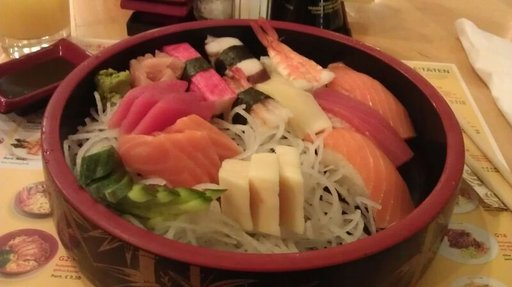

In [29]:
import random 
from PIL import Image 

random.seed(42)

image_path_list = list(image_path.glob('*/*/*.jpg'))

random_image_path = random.choice(image_path_list)
# print(random_image_path)

image_class = random_image_path.parent.stem
# print(image_class)

img = Image.open(random_image_path)
print(f"Image path: {random_image_path}")
print(f"Class name: {image_class}")
print(f"Height: {img.height}")
print(f"Width: {img.width}")
img

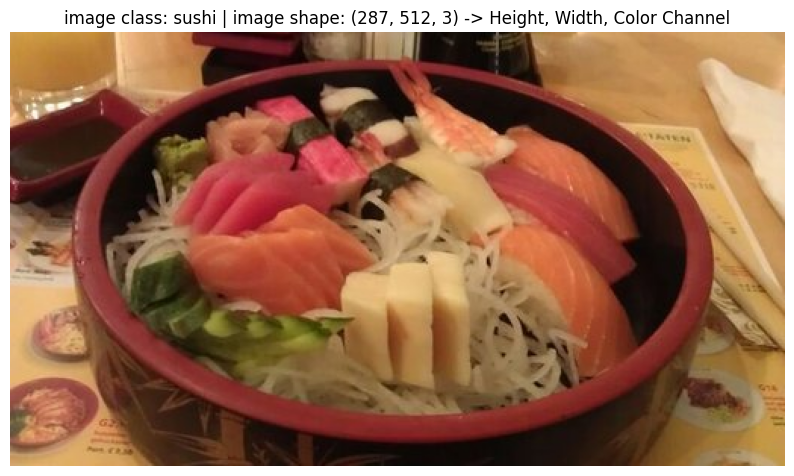

In [30]:
import numpy as np 
import matplotlib.pyplot as plt 

image_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(image_array)
plt.title(f"image class: {image_class} | image shape: {image_array.shape} -> Height, Width, Color Channel")
plt.axis("off")
plt.show()

#### 3. Transform Data

In [31]:
import torchvision

In [32]:
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [68]:
transforms_data = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ToTensor() ])

In [69]:
transforms_data(img)

tensor([[[0.8118, 0.8157, 0.8235,  ..., 0.8000, 0.7843, 0.7882],
         [0.8039, 0.8039, 0.8118,  ..., 0.8157, 0.7922, 0.7922],
         [0.7961, 0.7961, 0.8000,  ..., 0.8314, 0.8118, 0.8000],
         ...,
         [0.7765, 0.7765, 0.7765,  ..., 0.7451, 0.7451, 0.7647],
         [0.8078, 0.8000, 0.8078,  ..., 0.7608, 0.7451, 0.7569],
         [0.8275, 0.8196, 0.8314,  ..., 0.7647, 0.7608, 0.7529]],

        [[0.6078, 0.6157, 0.6196,  ..., 0.6275, 0.6118, 0.6039],
         [0.6000, 0.6039, 0.6039,  ..., 0.6431, 0.6196, 0.6039],
         [0.5922, 0.5922, 0.5922,  ..., 0.6588, 0.6353, 0.6118],
         ...,
         [0.5922, 0.6039, 0.6118,  ..., 0.6078, 0.5961, 0.5843],
         [0.6157, 0.6196, 0.6314,  ..., 0.6353, 0.6039, 0.5922],
         [0.6471, 0.6549, 0.6627,  ..., 0.6431, 0.6235, 0.5961]],

        [[0.3020, 0.2902, 0.2824,  ..., 0.4118, 0.3961, 0.3922],
         [0.2902, 0.2745, 0.2667,  ..., 0.4235, 0.4000, 0.3922],
         [0.2784, 0.2627, 0.2549,  ..., 0.4314, 0.4078, 0.

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

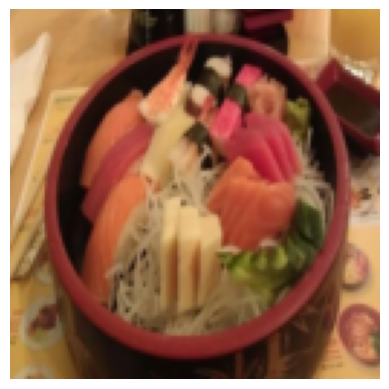

In [70]:
plt.imshow(transforms_data(img).permute(1,2,0))
plt.axis("off")

In [71]:
def plot_transformed_image(image_path_list, transforms, n=3, seed=42):
    random.seed(seed)
    random_image_path = random.sample(image_path_list, k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as f: 
            fig, ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\n size:{f.size}")
            ax[0].axis("off")
            
            transformed_image = transforms(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\n size:{transformed_image.shape}")
            ax[1].axis("off")
            
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


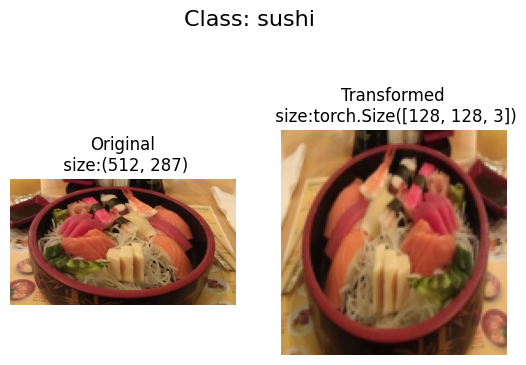

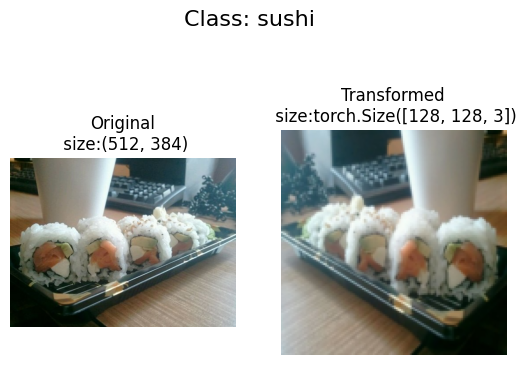

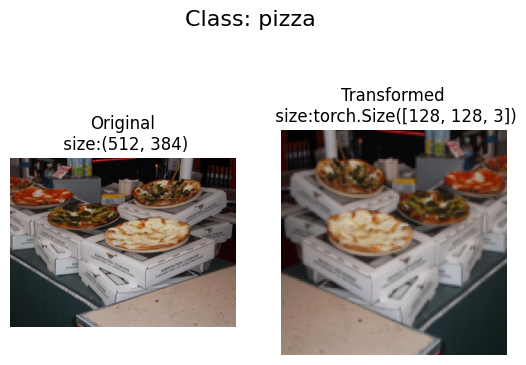

In [72]:
plot_transformed_image(image_path_list=image_path_list, 
                       transforms=transforms_data, )